In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/weight-height.csv")

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipython-input-4001906372.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

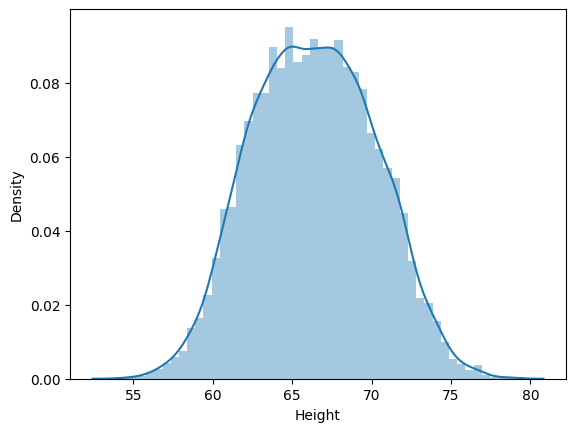

In [6]:
import seaborn as sns
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

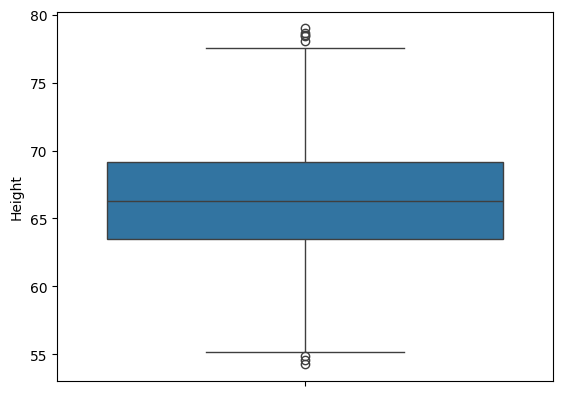

In [7]:
sns.boxplot(df['Height'])

In [10]:
#HERE WE ARE DECIDING THE QUANTILE THAT WE WANT TO USE IN ORDER TO FIGURE OUT THE OUTLIERS
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01) #less than 1 percentile


#ONE THING THAT IS TO BE NOTED THAT WE LEAVE THE EQUAL NUMBERS ON BOTH THE SIDES - IT SHOULD BE SYUMMERTRIC
#meaning that if the upere_limitnis 99 = 100-1  than the lower limit iss the that remaining 1 percentile

In [11]:
upper_limit

np.float64(74.7857900583366)

In [12]:
lower_limit

np.float64(58.13441158671655)

In [15]:
df[(df['Height'] >=74.78) |(df['Height']<58.3)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9809,Female,58.260965,104.872612
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [18]:
#TRIMMING
new_df = df[(df['Height'] <74.78) & (df['Height']>58.3)]

In [19]:
new_df['Height'].describe()

,Height
count,9786.000000
mean,66.374362
std,3.634487
min,58.300268
25%,63.583838
50%,66.324053
75%,69.121356
max,74.767447


<Axes: ylabel='Height'>

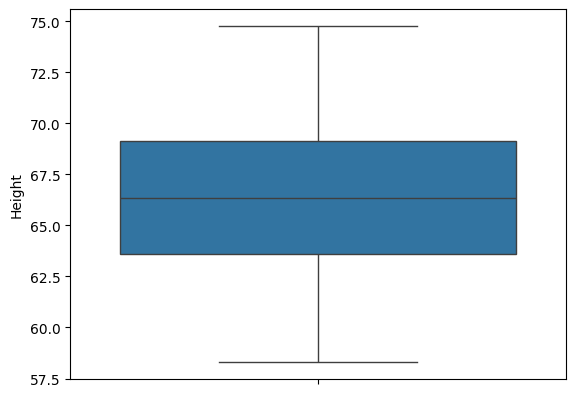

In [20]:
sns.boxplot(new_df['Height'])

/tmp/ipython-input-1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

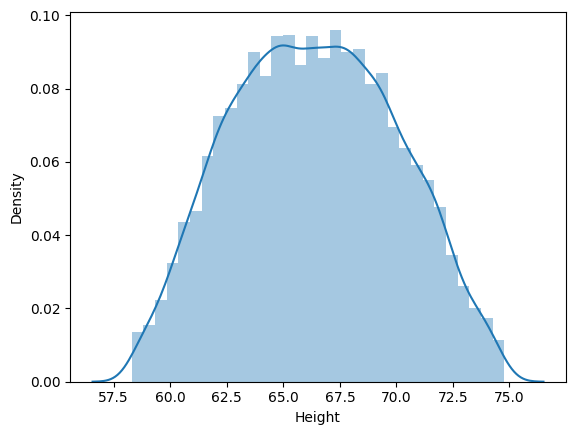

In [21]:
sns.distplot(new_df['Height'])

In [24]:
# CAPPING - WINSORISATION
df['Height'] = np.where(df['Height']>upper_limit , upper_limit, np.where(df['Height']<lower_limit , lower_limit , df['Height']))

In [26]:
df['Height'].describe()

#as it can we seen - the min and max value has been changed

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


/tmp/ipython-input-3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

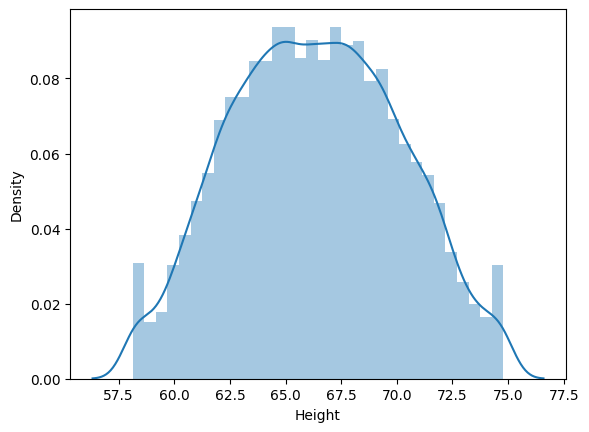

In [27]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

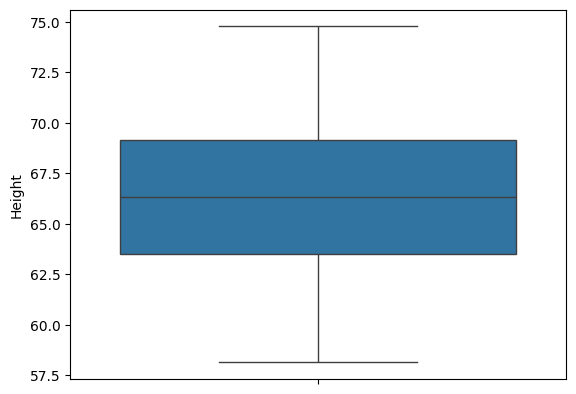

In [28]:
sns.boxplot(df['Height'])